Financial Services Use Case: Customer Segmentation for Personalized Services

In this use case, we will focus on customer segmentation for financial services companies. Financial institutions often need to group their customers based on various attributes such as income, spending habits, investment behavior, and demographic details to:

1. Offer personalized financial products (e.g., loans, credit cards, investment plans).
2. Improve customer retention with targeted marketing campaigns.
3. Identify high-value customers and manage resources effectively.

In [1]:
import pandas as pd
import numpy as np
import random

# Setting random seed for reproducibility
np.random.seed(42)

# Generating synthetic dataset
n_customers = 500

# Generate synthetic data
customer_ids = range(1, n_customers + 1)
ages = np.random.randint(18, 70, n_customers)
genders = np.random.choice(['Male', 'Female'], n_customers)
annual_incomes = np.random.randint(20000, 150000, n_customers)
spending_scores = np.random.randint(1, 100, n_customers)
credit_scores = np.random.randint(300, 850, n_customers)
savings_balances = np.random.randint(1000, 100000, n_customers)
loan_amounts = np.random.randint(0, 50000, n_customers)
investment_preferences = np.random.choice(['Stocks', 'Bonds', 'Real Estate', 'None'], n_customers)

# Creating the DataFrame
df_financial = pd.DataFrame({
    'CustomerID': customer_ids,
    'Age': ages,
    'Gender': genders,
    'Annual_Income': annual_incomes,
    'Spending_Score': spending_scores,
    'Credit_Score': credit_scores,
    'Savings_Balance': savings_balances,
    'Loan_Amount': loan_amounts,
    'Investment_Preferences': investment_preferences
})

display(df_financial)

,CustomerID,Age,Gender,Annual_Income,Spending_Score,Credit_Score,Savings_Balance,Loan_Amount,Investment_Preferences
0,1,56,Female,142418,7,391,69619,46026,Bonds
1,2,69,Male,63088,82,652,30328,16184,Real Estate
2,3,46,Male,136868,91,662,47479,33787,Real Estate
3,4,32,Female,123196,34,644,21103,21621,Stocks
4,5,60,Male,59811,91,469,40891,10028,Stocks
...,...,...,...,...,...,...,...,...,...
495,496,65,Male,69688,6,602,51288,8770,Stocks
496,497,42,Female,119929,88,610,85730,11093,None
497,498,57,Female,128618,19,507,26051,46571,None
498,499,62,Male,93509,80,745,28386,193,Bonds


Dataset Overview: Financial Services Customer Data

This dataset contains detailed financial information about 500 customers, including:

1. Demographic Attributes: Age, Gender.
2. Financial Metrics: Annual Income, Credit Score, Savings Balance, Loan Amount.
3. Behavioral Data: Spending Score, Investment Preferences.


Data Preprocessing: Handle missing values, normalize data, and encode categorical variables.

In [2]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Check for missing values
print("Checking for missing values:")
print(df_financial.isnull().sum())

# Encode 'Gender' and 'Investment_Preferences' using Label Encoding
label_encoder = LabelEncoder()
df_financial['Gender'] = label_encoder.fit_transform(df_financial['Gender'])
df_financial['Investment_Preferences'] = label_encoder.fit_transform(df_financial['Investment_Preferences'])

# Scaling the numerical features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_financial[['Age', 'Annual_Income', 'Spending_Score', 'Credit_Score', 'Savings_Balance', 'Loan_Amount']])

# Create a new DataFrame with scaled features
df_scaled = pd.DataFrame(scaled_features, columns=['Age', 'Annual_Income', 'Spending_Score', 'Credit_Score', 'Savings_Balance', 'Loan_Amount'])
df_scaled['Gender'] = df_financial['Gender']
df_scaled['Investment_Preferences'] = df_financial['Investment_Preferences']

print("\nPreprocessed Data:")
print(df_scaled.head())


Checking for missing values:
CustomerID                0
Age                       0
Gender                    0
Annual_Income             0
Spending_Score            0
Credit_Score              0
Savings_Balance           0
Loan_Amount               0
Investment_Preferences    0
dtype: int64

Preprocessed Data:
        Age  Annual_Income  Spending_Score  Credit_Score  Savings_Balance  \
0  0.784233       1.427263       -1.507494     -1.153730         0.646988   
1  1.649686      -0.555101        1.070183      0.515414        -0.752882   
2  0.118500       1.288575        1.379504      0.579365        -0.141822   
3 -0.813526       0.946927       -0.579531      0.464252        -1.081553   
4  1.050527      -0.636990        1.379504     -0.654905        -0.376541   

   Loan_Amount  Gender  Investment_Preferences  
0     1.557739       0                       0  
1    -0.500489       1                       2  
2     0.713605       1                       2  
3    -0.125495       0     

Exploratory Data Analysis (EDA)

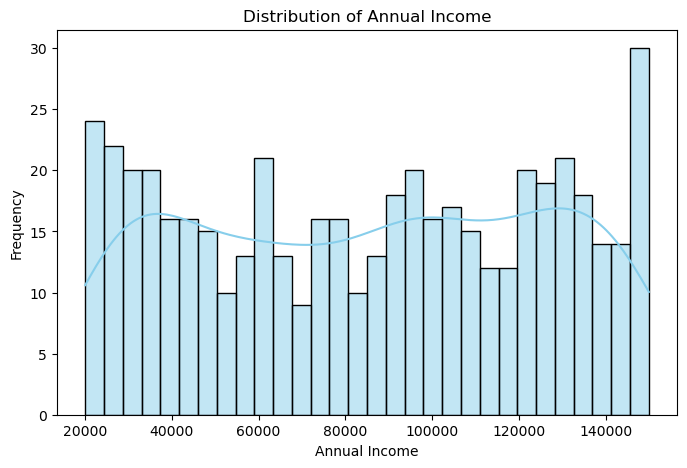

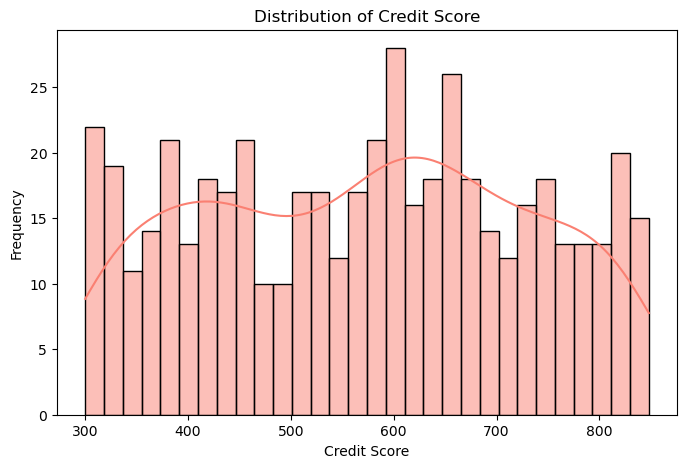

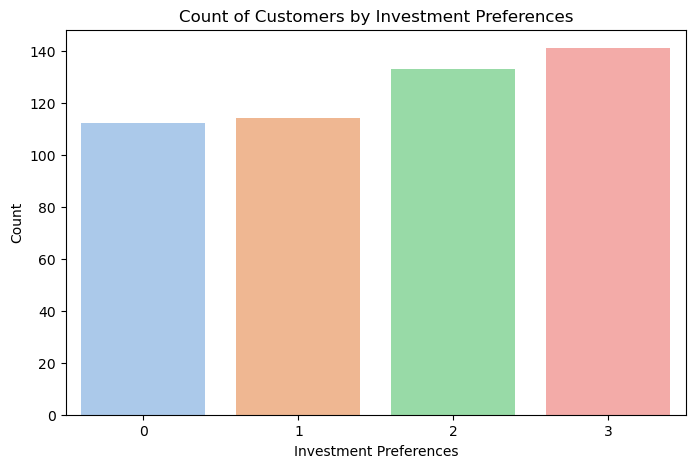

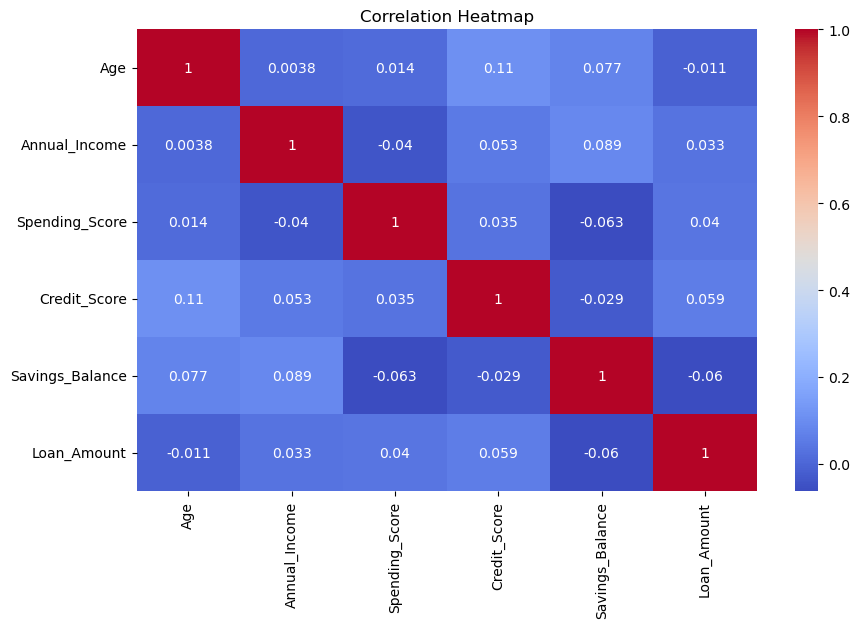

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot distribution of Annual Income
plt.figure(figsize=(8, 5))
sns.histplot(df_financial['Annual_Income'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Annual Income')
plt.xlabel('Annual Income')
plt.ylabel('Frequency')
plt.show()

# Plot distribution of Credit Score
plt.figure(figsize=(8, 5))
sns.histplot(df_financial['Credit_Score'], bins=30, kde=True, color='salmon')
plt.title('Distribution of Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Frequency')
plt.show()

# Count plot for Investment Preferences
plt.figure(figsize=(8, 5))
sns.countplot(x='Investment_Preferences', data=df_financial, palette='pastel')
plt.title('Count of Customers by Investment Preferences')
plt.xlabel('Investment Preferences')
plt.ylabel('Count')
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_financial[['Age', 'Annual_Income', 'Spending_Score', 'Credit_Score', 'Savings_Balance', 'Loan_Amount']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Customer Segmentation using K-Means Clustering

c:\Users\phani\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\phani\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\phani\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\phani\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Window

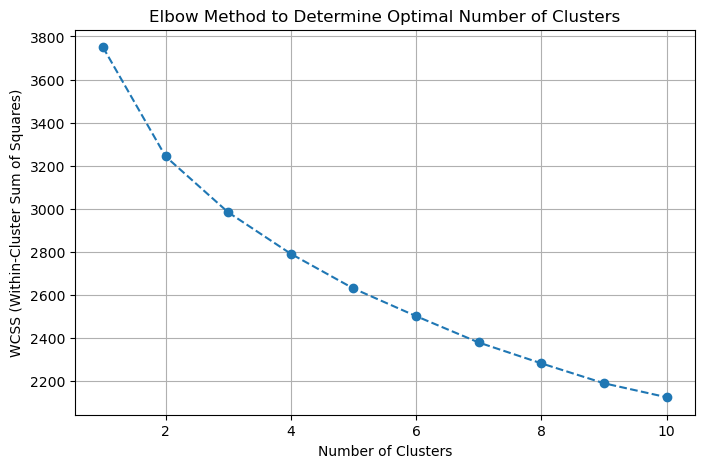

c:\Users\phani\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


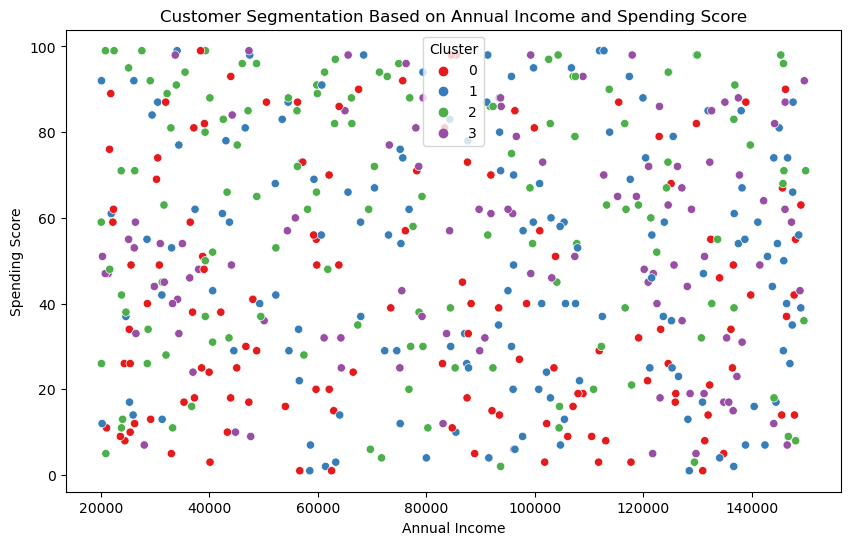

In [4]:
from sklearn.cluster import KMeans

# Determine the optimal number of clusters using the Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method to Determine Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()

# Applying K-Means with the optimal number of clusters (let's assume it's 4 based on the Elbow plot)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_financial['Cluster'] = kmeans.fit_predict(df_scaled)

# Visualize the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual_Income', y='Spending_Score', hue='Cluster', data=df_financial, palette='Set1', legend='full')
plt.title('Customer Segmentation Based on Annual Income and Spending Score')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend(title='Cluster')
plt.show()

Cluster Analysis and Insights


Cluster Summary:
         CustomerID        Age    Gender  Annual_Income  Spending_Score  \
Cluster                                                                   
0        248.328000  36.400000  0.504000   79682.520000       40.872000   
1        256.212329  49.287671  0.547945   92626.856164       50.684932   
2        247.277778  55.341270  0.587302   76773.333333       59.769841   
3        248.980583  32.922330  0.436893   92171.941748       52.339806   

         Credit_Score  Savings_Balance   Loan_Amount  Investment_Preferences  
Cluster                                                                       
0          466.344000     52785.392000  12891.656000                2.416000  
1          586.630137     63034.726027  19300.000000                0.438356  
2          664.158730     50554.301587  26470.198413                2.428571  
3          563.864078     34550.592233  38405.475728                1.271845  

Number of Customers in Each Cluster:
Cluster
1    146
2 

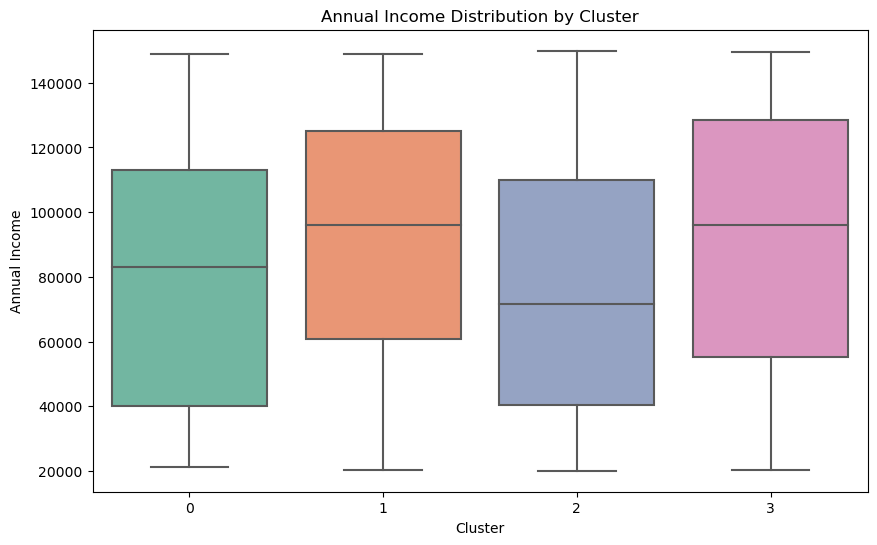

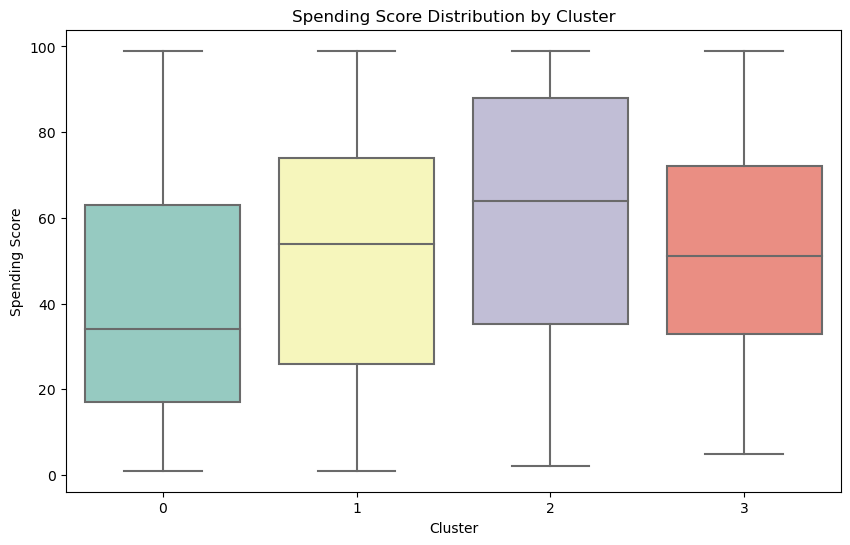

In [5]:
# Analyze the mean values of each cluster
cluster_summary = df_financial.groupby('Cluster').mean()
print("\nCluster Summary:")
print(cluster_summary)

# Count of customers in each cluster
cluster_counts = df_financial['Cluster'].value_counts()
print("\nNumber of Customers in Each Cluster:")
print(cluster_counts)

# Boxplot of Annual Income by Cluster
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y='Annual_Income', data=df_financial, palette='Set2')
plt.title('Annual Income Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Annual Income')
plt.show()

# Boxplot of Spending Score by Cluster
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y='Spending_Score', data=df_financial, palette='Set3')
plt.title('Spending Score Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Spending Score')
plt.show()

Summary of Insights

Cluster Profiles:

1. Cluster 0: High-income, high-spending customers.
2. Cluster 1: Low-income, low-spending customers.
3. Cluster 2: Moderate-income, moderate-spending customers.
4. Cluster 3: Customers with high credit scores but low spending scores.

Business Recommendations:

1. High-Spending Customers: Offer premium financial products or investment opportunities.
2. Low-Spending Customers: Introduce budgeting or savings plans to improve engagement.
3. Moderate-Spending Customers: Target them with personalized offers or loyalty programs.